# Análise de Dados de Wearables — PAMAP2

**Objetivo:** Ganhar proficiência com bibliotecas de Data Science (pandas, scikit-learn, seaborn) aplicadas a um problema real de classificação de atividades físicas.

O pipeline cobre três etapas principais:
1. Carregamento e limpeza dos dados brutos do dataset PAMAP2
2. Análise exploratória
3. Três tarefas de ML/análise: classificação (caminhada/corrida/descanso), detecção de intensidade e estimativa de gasto calórico

**Em razão do Dataset muito robusto, optei por inserir os outputs direto no Notebook, sem necessidade de execução uma vez que fiquei impossibilitado de fazer upload dos arquivos**

## 1. Imports e configuração

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## 2. Estrutura do Dataset

O PAMAP2 contém leituras de três sensores IMU (mão, peito e calcanhar) de 9 indivíduos realizando até 18 atividades diferentes. Metadados: mapeamento de IDs de atividade, caminhos dos arquivos e nomes das colunas.

In [2]:
id_atividades = {
    0: 'transient',       1: 'lying',            2: 'sitting',
    3: 'standing',        4: 'walking',           5: 'running',
    6: 'cycling',         7: 'Nordic_walking',    9: 'watching_TV',
    10: 'computer_work',  11: 'car driving',      12: 'ascending_stairs',
    13: 'descending_stairs', 16: 'vacuum_cleaning', 17: 'ironing',
    18: 'folding_laundry', 19: 'house_cleaning',  20: 'playing_soccer',
    24: 'rope_jumping'
}

lista_dados = [
    '/Wearables/PAMAP2_Dataset/Protocol/subject101.dat',
    '/Wearables/PAMAP2_Dataset/Protocol/subject102.dat',
    '/Wearables/PAMAP2_Dataset/Protocol/subject103.dat',
    '/Wearables/PAMAP2_Dataset/Protocol/subject104.dat',
    '/Wearables/PAMAP2_Dataset/Protocol/subject105.dat',
    '/Wearables/PAMAP2_Dataset/Protocol/subject106.dat',
    '/Wearables/PAMAP2_Dataset/Protocol/subject107.dat',
    '/Wearables/PAMAP2_Dataset/Protocol/subject108.dat',
    '/Wearables/PAMAP2_Dataset/Protocol/subject109.dat',
]

col_geral          = ['timestamp', 'id_atividade', 'Frequência cardiaca (bpm)']

col_dados_mao      = ['mTemperatura',
                      'mAcel 16g (ms) 1', 'mAcel 16g (ms) 2', 'mAcel 16g (ms) 3',
                      'mAcel 6g (ms) 1',  'mAcel 6g (ms) 2',  'mAcel 6g (ms) 3',
                      'mGyro (rad/s) 1',  'mGyro (rad/s) 2',  'mGyro (rad/s) 3',
                      'mMag (μT) 1',      'mMag (μT) 2',      'mMag (μT) 3',
                      'mOrientação 1',    'mOrientação 2',    'mOrientação 3', 'mOrientação 4']

col_dados_peito    = ['pTemperatura',
                      'pAcel 16g (ms) 1', 'pAcel 16g (ms) 2', 'pAcel 16g (ms) 3',
                      'pAcel 6g (ms) 1',  'pAcel 6g (ms) 2',  'pAcel 6g (ms) 3',
                      'pGyro (rad/s) 1',  'pGyro (rad/s) 2',  'pGyro (rad/s) 3',
                      'pMag (μT) 1',      'pMag (μT) 2',      'pMag (μT) 3',
                      'pOrientação 1',    'pOrientação 2',    'pOrientação 3', 'pOrientação 4']

col_dados_calcanhar = ['cTemperatura',
                       'cAcel 16g (ms) 1', 'cAcel 16g (ms) 2', 'cAcel 16g (ms) 3',
                       'cAcel 6g (ms) 1',  'cAcel 6g (ms) 2',  'cAcel 6g (ms) 3',
                       'cGyro (rad/s) 1',  'cGyro (rad/s) 2',  'cGyro (rad/s) 3',
                       'cMag (μT) 1',      'cMag (μT) 2',      'cMag (μT) 3',
                       'cOrientação 1',    'cOrientação 2',    'cOrientação 3', 'cOrientação 4']

colunas = col_geral + col_dados_mao + col_dados_peito + col_dados_calcanhar

## 3. Carregamento e limpeza dos dados

In [ ]:
dados_completos = pd.DataFrame()

for arq in lista_dados:
    proc_dados = pd.read_table(filepath_or_buffer=arq, header=None, sep=r'\s+')
    proc_dados.columns = colunas
    dados_completos = pd.concat([dados_completos, proc_dados], ignore_index=True)


def LimpaDados(df):
    colunas_orientacao = [
        'cOrientação 1', 'cOrientação 2', 'cOrientação 3', 'cOrientação 4',
        'mOrientação 1', 'mOrientação 2', 'mOrientação 3', 'mOrientação 4',
        'pOrientação 1', 'pOrientação 2', 'pOrientação 3', 'pOrientação 4',
    ]
    df = df.drop(columns=colunas_orientacao)
    df = df.drop(df[df.id_atividade == 0].index)   # remove amostras de transição
    df = df.apply(lambda x: pd.to_numeric(x, errors='coerce'))
    df = df.interpolate()                           # preenche NaN por interpolação linear
    return df


dn = LimpaDados(dados_completos)
dn.reset_index(drop=True, inplace=True)
dn.head(10)

In [ ]:
   timestamp  id_atividade  Frequência cardiaca (bpm)  mTemperatura  mAcel 16 g (ms) 1  ...  cGyro (rad/s) 2  cGyro (rad/s) 3  cMag (μT) 1  cMag (μT) 2  cMag (μT) 3
0      37.66             1                        NaN        30.375           2.21530  ...        -0.027714         0.001752     -61.1081     -36.8636     -58.3696
1      37.67             1                        NaN        30.375           2.29196  ...         0.000945         0.006007     -60.8916     -36.3197     -58.3656
2      37.68             1                        NaN        30.375           2.29090  ...        -0.052422        -0.004882     -60.3407     -35.7842     -58.6119
3      37.69             1                        NaN        30.375           2.21800  ...        -0.018844         0.026950     -60.7646     -37.1028     -57.8799
4      37.70             1                      100.0        30.375           2.30106  ...        -0.048878        -0.006328     -60.2040     -37.1225     -57.8847
5      37.71             1                      100.0        30.375           2.07165  ...        -0.026906         0.004125     -61.3257     -36.9744     -57.7501
6      37.72             1                      100.0        30.375           2.41148  ...        -0.032277        -0.006866     -61.5520     -36.9632     -57.9957
7      37.73             1                      100.0        30.375           2.32815  ...        -0.016621         0.006548     -61.5738     -36.1724     -59.3487
8      37.74             1                      100.0        30.375           2.25096  ...         0.020393        -0.011880     -61.7741     -37.1744     -58.1199
9      37.75             1                      100.0        30.375           2.14107  ...        -0.010763         0.005133     -60.7680     -37.4206     -58.8735

## 4. Divisão treino / teste

Foram separados 80% dos dados para treino e 20% para teste usando amostragem aleatória. O random_state garante reprodutibilidade.


In [ ]:
treino_Dn = dn.sample(frac=0.8, random_state=1)
teste_Dn  = dn.drop(treino_Dn.index)

## 5. Análise exploratória — Frequência Cardíaca

O boxplot da frequência cardíaca nos dá uma visão rápida da distribuição geral: mediana, dispersão e possíveis outliers. Isso ajuda a calibrar os limiares usados na detecção de intensidade mais adiante.

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
plt.title('FC (BPM)')
sns.boxplot(y=treino_Dn['Frequência cardiaca (bpm)'], ax=ax)
plt.tight_layout()
plt.show()

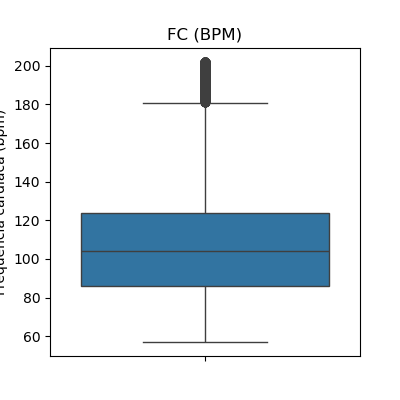

## 6. Classificação: caminhada / corrida / descanso

Filtrou-se três classes de interesse para uma feature de magnitude do acelerômetro.

O modelo escolhido é o Random Forest: lida bem com dados ruidosos de sensores, não exige normalização e fornece importância de features nativamente. O classification_report ao final mostra precisão, recall e F1 por classe.

In [ ]:
mapa_atividades = {1: 'descanso', 2: 'descanso', 3: 'descanso',
                   4: 'caminhada', 5: 'corrida'}

df_filtrado = dn[dn['id_atividade'].isin(mapa_atividades.keys())].copy()
df_filtrado['rotulo'] = df_filtrado['id_atividade'].map(mapa_atividades)

# Magnitude euclidiana do acelerômetro de 16g para cada sensor
for prefixo in ['m', 'p', 'c']:
    df_filtrado[f'{prefixo}Magnitude'] = np.sqrt(
        df_filtrado[f'{prefixo}Acel 16g (ms) 1']**2 +
        df_filtrado[f'{prefixo}Acel 16g (ms) 2']**2 +
        df_filtrado[f'{prefixo}Acel 16g (ms) 3']**2
    )

caracteristicas = ['Frequência cardiaca (bpm)',
                   'mMagnitude', 'pMagnitude', 'cMagnitude']

X = df_filtrado[caracteristicas]
y = df_filtrado['rotulo']

X_treino = X.loc[treino_Dn.index.intersection(X.index)]
y_treino = y.loc[X_treino.index]
X_teste  = X.loc[teste_Dn.index.intersection(X.index)]
y_teste  = y.loc[X_teste.index]

classificador = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
classificador.fit(X_treino, y_treino)

print(classification_report(y_teste, classificador.predict(X_teste)))

In [ ]:
              precision    recall  f1-score   support

   caminhada       0.97      0.98      0.98     47936
     corrida       0.98      0.94      0.96     19744
    descanso       0.99      0.99      0.99    113233

    accuracy                           0.98    180913
   macro avg       0.98      0.97      0.98    180913
weighted avg       0.98      0.98      0.98    180913

## 7. Detecção de intensidade do exercício

Classificamos cada amostra em três zonas de intensidade com base na frequência cardíaca, abordagem padrão da fisiologia do exercício:

| Zona | FC (bpm) |
|------|----------|
| Baixa | < 100 |
| Moderada | 100 – 139 |
| Alta | ≥ 140 |

In [ ]:
def classificar_intensidade(bpm):
    if bpm < 100:
        return 'baixa'
    elif bpm < 140:
        return 'moderada'
    else:
        return 'alta'

dn['intensidade'] = dn['Frequência cardiaca (bpm)'].apply(classificar_intensidade)

fig, eixo = plt.subplots(figsize=(12, 5))
contagem_intensidade = (dn.groupby(['id_atividade', 'intensidade'])
                          .size()
                          .unstack(fill_value=0))
contagem_intensidade.plot(kind='bar', stacked=True, ax=eixo, colormap='RdYlGn_r')
eixo.set_xlabel('ID da Atividade')
eixo.set_ylabel('Número de amostras')
eixo.set_title('Distribuição de Intensidade por Atividade')
plt.tight_layout()
plt.show()

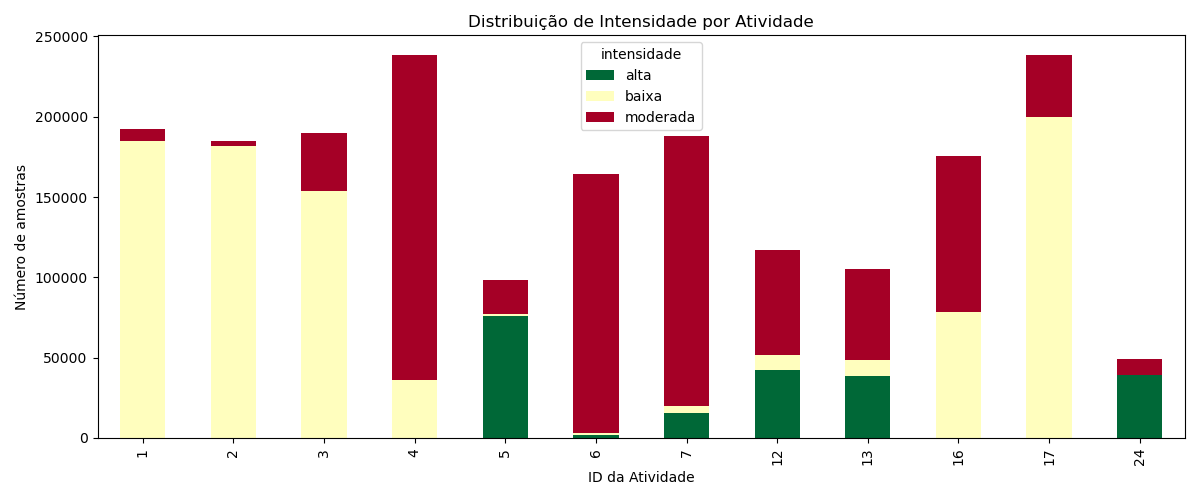

## 8. Estimativa de gasto calórico

Foi utilizado o método **MET (Metabolic Equivalent of Task)**, padrão na literatura de wearables quando não há medição direta de VO₂.

A fórmula é:

$$\text{kcal} = \text{MET} \times \text{peso}_{kg} \times \text{tempo}_{horas}$$

PAMAP2 é amostrado a 100 Hz, cada linha representa 1/100 s. O cálculo é feito de forma vetorizada com .map().

In [ ]:
valores_met = {
    1: 0.9,   # lying
    2: 1.0,   # sitting
    3: 1.2,   # standing
    4: 3.5,   # walking
    5: 8.0,   # running
    6: 6.0,   # cycling
    7: 4.5,   # Nordic walking
    12: 4.0,  # ascending stairs
    13: 3.0,  # descending stairs
    16: 3.5,  # vacuum cleaning
    17: 2.3,  # ironing
    20: 7.0,  # playing soccer
    24: 10.0, # rope jumping
}

PESO_CORPORAL = 70
SAMPLE_RATE_HZ = 100       
SEC_POR_SAMPLE = 1 / SAMPLE_RATE_HZ

def estimate_calorias(row, peso_kg= PESO_CORPORAL):
    met = valores_met.get(int(row['id_atividade']), 1.0)
    horas = SEC_POR_SAMPLE / 3600
    return met * peso_kg * horas     # kcal = MET × peso(kg) × tempo(horas)

dn['a'] = dn.apply(estimate_calorias, axis=1)

# Calorias por atividade

dn['id_atividade'] = dn['id_atividade'].fillna(0).astype(int)
dn['met'] = dn['id_atividade'].map(valores_met).fillna(1.0)
dn['calorias_kcal'] = dn['met'] * PESO_CORPORAL * (SEC_POR_SAMPLE / 3600)
dn.drop(columns=['met'], inplace=True)

resumo_calorias = dn.groupby('id_atividade')['calorias_kcal'].sum().reset_index()
resumo_calorias.columns = ['ID Atividade', 'Total kcal']
resumo_calorias['Atividade'] = resumo_calorias['ID Atividade'].map(id_atividades)
print(resumo_calorias.sort_values('Total kcal', ascending=False))


In [ ]:
    ID Atividade  Total kcal          Atividade
5              6  192.033333            cycling
6              7  164.593625     Nordic_walking
3              4  162.490125            walking
4              5  152.754000            running
9             16  119.337458    vacuum_cleaning
10            17  106.747472            ironing
11            24   95.977778       rope_jumping
7             12   91.168000   ascending_stairs
8             13   61.217333  descending_stairs
2              3   44.317233           standing
1              2   36.008778            sitting
0              1   33.691525              lying